# Communication Dropout Diagnostics

Run `scripts/diagnose_joint_happo.py` for a communication-dropout sweep, or provide an existing `FILELIST` of diagnostic JSON files to skip rerunning diagnostics. The notebook compares the core joint performance metrics:

- scout recall: mean and std
- confirmation recall: mean and std
- full-confirm success: rate and binary std
- final confidence: mean and std
- final coverage: mean and std

Edit the sweep settings in the first code cell. If `FILELIST` is empty, the notebook writes one JSON and one diagnostics plot per dropout value, then reads those JSONs. If `FILELIST` is non-empty, it reads those files directly and does not launch diagnostics.

In [49]:
# Sweep configuration. Set CKPT explicitly, or leave it as None to use the newest run under MODLABEL.
MODLABEL = 'uav4_ugv3_1km_256'
CKPT = "/Users/aschuetz/Software/capstone/omnisearch/results/harl_runs/wildfire/wildfire_search/happo/uav4_ugv3_1km_256_190_900_hid128/seed-00001-2026-07-18-00-05-21/models"
NSTEPS_PER_EPISODE = 900
SEED_START = 1000
SEED_END = 1049
DROPOUTS = [0.0,0.3,0.5,0.7,0.9,1.0]

RUN_DIAGNOSTICS = True
FORCE_RERUN_DIAGNOSTICS = True
COMMS_DROPOUT_MODE = 'bursty'
COMMS_MAP_MODE = 'per_agent'
COMMS_DROPOUT_MIN_STEPS = 5
COMMS_DROPOUT_MAX_STEPS = 15

# Optional: provide existing diagnose_joint_happo.py JSON outputs here to skip rerunning diagnostics.
#FILELIST = []
FILELIST = [
     'outputs/uav4_ugv3_1km_256_254_900_hid128_fire_nsurv_min5_max5_obs5_1000_1049.json',
     'outputs/uav4_ugv3_1km_256_254_900_hid128_fire_nsurv_min5_max5_obs5_1000_1049.json',
     'outputs/uav4_ugv3_1km_256_254_900_hid128_fire_nsurv_min5_max5_obs5_1000_1049.json',
     'outputs/uav4_ugv3_1km_256_254_900_hid128_fire_nsurv_min5_max5_obs5_1000_1049.json',
     'outputs/uav4_ugv3_1km_256_254_900_hid128_fire_nsurv_min5_max5_obs5_1000_1049.json',
     'outputs/uav4_ugv3_1km_256_254_900_hid128_fire_nsurv_min5_max5_obs5_1000_1049.json',
]

# Optional display labels for FILELIST entries. Leave empty to derive labels from JSON metadata / filenames.
LABELS = []
LABELS = ['0.0','0.3','0.5','0.7','0.9','1.0']



In [50]:
import json
import shlex
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
if (CWD / 'scripts' / 'diagnose_joint_happo.py').is_file():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'scripts' / 'diagnose_joint_happo.py').is_file():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = Path('..').resolve()

OUTPUT_DIR = PROJECT_ROOT / 'outputs'
RESULTS_ROOT = PROJECT_ROOT / 'results/harl_runs/wildfire/wildfire_search/happo'

def _resolve_checkpoint(ckpt):
    if ckpt is not None:
        ckpt = Path(ckpt).expanduser()
        if not ckpt.is_absolute():
            ckpt = PROJECT_ROOT / ckpt
        if not ckpt.is_dir():
            raise FileNotFoundError(f'Checkpoint directory not found: {ckpt}')
        return ckpt.resolve()

    candidates = sorted((RESULTS_ROOT / MODLABEL).glob('seed-*/models'), key=lambda p: p.stat().st_mtime)
    if not candidates:
        raise FileNotFoundError(
            f'No checkpoint found under {RESULTS_ROOT / MODLABEL}. '
            'Set CKPT to the checkpoint models directory.'
        )
    return candidates[-1].resolve()


def _dropout_probability(dropout):
    value = float(dropout)
    return value / 100.0 if value > 1.0 else value


def _dropout_cli_value(dropout):
    return f'{_dropout_probability(dropout):g}'


def _dropout_tag(dropout):
    value = _dropout_probability(dropout)
    digits = f'{value:.2f}'.split('.')[1].rstrip('0') or '0'
    return digits.zfill(2)


def _diagnostic_output_paths(dropout):
    tag = _dropout_tag(dropout)
    stem = f'{MODLABEL}_comms{tag}_{SEED_START}_{SEED_END}'
    return OUTPUT_DIR / f'{stem}.json', OUTPUT_DIR / f'{stem}.png'



def _resolve_json_file(path):
    path = Path(path).expanduser()
    candidates = [path]
    if not path.is_absolute():
        candidates.extend([PROJECT_ROOT / path, PROJECT_ROOT / 'notebooks' / path])
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    return path.resolve() if path.is_absolute() else (PROJECT_ROOT / path).resolve()

if FILELIST ==[]:
    CKPT = _resolve_checkpoint(CKPT)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    print('Project root:', PROJECT_ROOT)
    print('Checkpoint:', CKPT)


In [51]:
if FILELIST:
    JSON_FILES = [_resolve_json_file(path) for path in FILELIST]
    print('Using provided file list; diagnostics will not be run.')
else:
    JSON_FILES = []
    seeds = [str(seed) for seed in range(SEED_START, SEED_END + 1)]

    for dropout in DROPOUTS:
        json_output, plots_output = _diagnostic_output_paths(dropout)
        if RUN_DIAGNOSTICS and (FORCE_RERUN_DIAGNOSTICS or not json_output.is_file()):
            cmd = [
                sys.executable,
                str(PROJECT_ROOT / 'scripts/diagnose_joint_happo.py'),
                '--checkpoint-dir', str(CKPT),
                '--steps', str(NSTEPS_PER_EPISODE),
                '--seeds', *seeds,
                '--comms-dropout', _dropout_cli_value(dropout),
                '--comms-dropout-mode', COMMS_DROPOUT_MODE,
                '--comms-map-mode', COMMS_MAP_MODE,
                '--comms-dropout-min-steps', str(COMMS_DROPOUT_MIN_STEPS),
                '--comms-dropout-max-steps', str(COMMS_DROPOUT_MAX_STEPS),
                '--json-output', str(json_output),
                '--plots-output', str(plots_output),
            ]
            print('\nRunning:', shlex.join(cmd))
            log_path = json_output.with_suffix('.log')
            print('This can take a while, please be patient. More details can be found in', log_path)
            with log_path.open('w') as log:
                subprocess.run(
                    cmd,
                    cwd=PROJECT_ROOT,
                    check=True,
                    stdout=log,
                    stderr=subprocess.STDOUT,
                )
        else:
            print('Using existing diagnostics:', json_output.relative_to(PROJECT_ROOT))
        JSON_FILES.append(json_output)

missing = [path for path in JSON_FILES if not path.is_file()]
if missing:
    raise FileNotFoundError('Missing diagnostic JSON files:\n' + '\n'.join(str(p) for p in missing))

print(f'Loaded file list: {len(JSON_FILES)} JSON file(s)')
for path in JSON_FILES:
    print(' -', path.relative_to(PROJECT_ROOT) if path.is_relative_to(PROJECT_ROOT) else path)


Using provided file list; diagnostics will not be run.
Loaded file list: 6 JSON file(s)
 - outputs/uav4_ugv3_1km_256_254_900_hid128_fire_nsurv_min5_max5_obs5_1000_1049.json
 - outputs/uav4_ugv3_1km_256_254_900_hid128_fire_nsurv_min5_max5_obs5_1000_1049.json
 - outputs/uav4_ugv3_1km_256_254_900_hid128_fire_nsurv_min5_max5_obs5_1000_1049.json
 - outputs/uav4_ugv3_1km_256_254_900_hid128_fire_nsurv_min5_max5_obs5_1000_1049.json
 - outputs/uav4_ugv3_1km_256_254_900_hid128_fire_nsurv_min5_max5_obs5_1000_1049.json
 - outputs/uav4_ugv3_1km_256_254_900_hid128_fire_nsurv_min5_max5_obs5_1000_1049.json


In [52]:
def _summary_value(summary, *keys, default=float('nan')):
    for key in keys:
        if key in summary:
            return summary[key]
    return default


def _payload_scenario(payload):
    scenario = payload.get('scenario')
    if isinstance(scenario, dict) and scenario:
        return scenario
    scenario_kwargs = payload.get('scenario_kwargs')
    if isinstance(scenario_kwargs, dict) and scenario_kwargs:
        return scenario_kwargs
    metadata = payload.get('metadata', {})
    scenario_kwargs = metadata.get('scenario_kwargs') if isinstance(metadata, dict) else None
    return scenario_kwargs if isinstance(scenario_kwargs, dict) else {}


def _success_rate(summary):
    rate = _summary_value(summary, 'full_confirm_success_rate', 'success_rate')
    if pd.isna(rate):
        percent = _summary_value(summary, 'full_confirm_success_percent')
        rate = percent / 100.0 if not pd.isna(percent) else float('nan')
    return rate


def _success_std(summary, rate):
    if pd.isna(rate):
        return float('nan')
    episodes = _summary_value(summary, 'episodes')
    if pd.isna(episodes) or episodes <= 0:
        return float('nan')
    return float(np.sqrt(max(rate * (1.0 - rate), 0.0)))


def _label_from_payload(path, payload):
    scenario = _payload_scenario(payload)
    dropout = scenario.get('comms_dropout', None)
    mode = scenario.get('comms_dropout_mode', None)
    if dropout is None:
        return path.stem
    return f'{path.stem} | dropout={dropout:g}, mode={mode or "?"}'


def _finite(values):
    return [float(v) for v in values if isinstance(v, (int, float, np.floating)) and np.isfinite(v)]


def _mean_std(values):
    values = _finite(values)
    if not values:
        return float('nan'), float('nan')
    return float(np.mean(values)), float(np.std(values))


def _episode_steps(row, scenario):
    for key in ('episode_steps', 'max_steps'):
        value = row.get(key)
        if isinstance(value, (int, float)) and value > 0:
            return int(value)
    value = scenario.get('max_steps')
    if isinstance(value, (int, float)) and value > 0:
        return int(value)
    return int(NSTEPS_PER_EPISODE)


def _active_survivor_indices(row):
    explicit = row.get('active_survivor_indices')
    if isinstance(explicit, list):
        return [int(idx) for idx in explicit]
    mask = row.get('active_survivor_mask')
    if isinstance(mask, list):
        return [idx for idx, active in enumerate(mask) if bool(active)]
    steps = row.get('first_scout_steps') or row.get('first_confirm_steps') or []
    count = row.get('active_survivors', row.get('survivors', len(steps)))
    try:
        count = int(count)
    except (TypeError, ValueError):
        count = len(steps)
    return list(range(min(count, len(steps))))


def _auc_from_first_steps(row, scenario, key):
    first_steps = row.get(key)
    if not isinstance(first_steps, list):
        return float('nan')
    steps = max(_episode_steps(row, scenario), 1)
    indices = _active_survivor_indices(row)
    if not indices:
        return 1.0
    total = 0.0
    for idx in indices:
        if idx >= len(first_steps):
            continue
        first_step = first_steps[idx]
        if first_step is None:
            continue
        try:
            first_step = float(first_step)
        except (TypeError, ValueError):
            continue
        if first_step <= 0:
            total += 1.0
        elif first_step <= steps:
            total += (steps - first_step + 1.0) / steps
    return float(total / max(len(indices), 1))


def _row_values(rows, *keys):
    values = []
    for row in rows:
        for key in keys:
            value = row.get(key)
            if isinstance(value, (int, float, np.floating)) and np.isfinite(value):
                values.append(float(value))
                break
    return values


def _summary_or_rows(summary, rows, mean_key, std_key, *row_keys, fallback=None):
    mean = _summary_value(summary, mean_key)
    std = _summary_value(summary, std_key)
    if not pd.isna(mean):
        return float(mean), float(std) if not pd.isna(std) else float('nan')
    values = _row_values(rows, *row_keys)
    if not values and fallback is not None:
        values = [fallback(row) for row in rows]
    return _mean_std(values)


if LABELS and len(LABELS) != len(JSON_FILES):
    raise ValueError(f'LABELS has {len(LABELS)} entries, but JSON_FILES has {len(JSON_FILES)} files')

configured_dropouts = []
if 'DROPOUTS' in globals() and len(DROPOUTS) == len(JSON_FILES):
    configured_dropouts = [_dropout_probability(value) for value in DROPOUTS]

records = []
for file_index, path in enumerate(JSON_FILES):
    payload = json.loads(path.read_text())
    summary = payload.get('summary', {})
    rows = payload.get('rows', [])
    scenario = _payload_scenario(payload)
    success_rate = _success_rate(summary)
    scout_auc_mean, scout_auc_std = _summary_or_rows(
        summary,
        rows,
        'mean_scout_auc',
        'std_scout_auc',
        'scout_auc',
        fallback=lambda row, scenario=scenario: _auc_from_first_steps(row, scenario, 'first_scout_steps'),
    )
    confirm_auc_mean, confirm_auc_std = _summary_or_rows(
        summary,
        rows,
        'mean_confirm_auc',
        'std_confirm_auc',
        'confirm_auc',
        'confirmation_auc',
        fallback=lambda row, scenario=scenario: _auc_from_first_steps(row, scenario, 'first_confirm_steps'),
    )
    coverage_auc_mean, coverage_auc_std = _summary_or_rows(
        summary,
        rows,
        'mean_coverage_auc',
        'std_coverage_auc',
        'coverage_auc',
    )
    confidence_auc_mean, confidence_auc_std = _summary_or_rows(
        summary,
        rows,
        'mean_confidence_auc',
        'std_confidence_auc',
        'confidence_auc',
    )
    metadata_dropout = scenario.get('comms_dropout', float('nan'))
    configured_dropout = configured_dropouts[file_index] if configured_dropouts else float('nan')
    dropout_x = configured_dropout if configured_dropouts else metadata_dropout
    records.append({
        'file': str(path),
        'label': str(LABELS[file_index]) if LABELS else _label_from_payload(path, payload),
        'episodes': _summary_value(summary, 'episodes', default=len(rows) if rows else float('nan')),
        'comms_dropout': metadata_dropout,
        'configured_dropout': configured_dropout,
        'dropout_x': dropout_x,
        'comms_dropout_mode': scenario.get('comms_dropout_mode', 'unknown'),
        'scout_recall_mean': _summary_value(summary, 'mean_scout_recall'),
        'scout_recall_std': _summary_value(summary, 'std_scout_recall'),
        'confirm_recall_mean': _summary_value(summary, 'mean_confirm_recall'),
        'confirm_recall_std': _summary_value(summary, 'std_confirm_recall'),
        'success_mean': success_rate,
        'success_std': _success_std(summary, success_rate),
        'success_count': _summary_value(summary, 'full_confirm_success_count'),
        'final_confidence_mean': _summary_value(summary, 'mean_final_confidence'),
        'final_confidence_std': _summary_value(summary, 'std_final_confidence'),
        'final_coverage_mean': _summary_value(summary, 'mean_final_coverage_fraction'),
        'final_coverage_std': _summary_value(summary, 'std_final_coverage_fraction'),
        'scout_auc_mean': scout_auc_mean,
        'scout_auc_std': scout_auc_std,
        'confirm_auc_mean': confirm_auc_mean,
        'confirm_auc_std': confirm_auc_std,
        'coverage_auc_mean': coverage_auc_mean,
        'coverage_auc_std': coverage_auc_std,
        'confidence_auc_mean': confidence_auc_mean,
        'confidence_auc_std': confidence_auc_std,
    })

metrics = pd.DataFrame.from_records(records)
metrics



,file,label,episodes,comms_dropout,configured_dropout,dropout_x,comms_dropout_mode,scout_recall_mean,scout_recall_std,confirm_recall_mean,...,final_coverage_mean,final_coverage_std,scout_auc_mean,scout_auc_std,confirm_auc_mean,confirm_auc_std,coverage_auc_mean,coverage_auc_std,confidence_auc_mean,confidence_auc_std
0,/Users/aschuetz/Software/capstone/omnisearch/o...,0.0,50.0,0.0,0.0,0.0,iid,0.992,0.039192,0.976,...,0.996503,0.003604,0.84088,0.067348,0.60808,0.105159,0.866398,0.009037,0.845296,0.009259
1,/Users/aschuetz/Software/capstone/omnisearch/o...,0.3,50.0,0.0,0.3,0.3,iid,0.992,0.039192,0.976,...,0.996503,0.003604,0.84088,0.067348,0.60808,0.105159,0.866398,0.009037,0.845296,0.009259
2,/Users/aschuetz/Software/capstone/omnisearch/o...,0.5,50.0,0.0,0.5,0.5,iid,0.992,0.039192,0.976,...,0.996503,0.003604,0.84088,0.067348,0.60808,0.105159,0.866398,0.009037,0.845296,0.009259
3,/Users/aschuetz/Software/capstone/omnisearch/o...,0.7,50.0,0.0,0.7,0.7,iid,0.992,0.039192,0.976,...,0.996503,0.003604,0.84088,0.067348,0.60808,0.105159,0.866398,0.009037,0.845296,0.009259
4,/Users/aschuetz/Software/capstone/omnisearch/o...,0.9,50.0,0.0,0.9,0.9,iid,0.992,0.039192,0.976,...,0.996503,0.003604,0.84088,0.067348,0.60808,0.105159,0.866398,0.009037,0.845296,0.009259
5,/Users/aschuetz/Software/capstone/omnisearch/o...,1.0,50.0,0.0,1.0,1.0,iid,0.992,0.039192,0.976,...,0.996503,0.003604,0.84088,0.067348,0.60808,0.105159,0.866398,0.009037,0.845296,0.009259


## Compact Table

The table below formats each metric as `mean +/- std` for quick comparison. 
AUC values are time-integrated performance scores; newer JSON files read them directly, 
and older files backfill scout/confirm AUC from first scout/confirm steps when available.


In [53]:
def _pm(mean, std):
    if pd.isna(mean):
        return 'n/a'
    if pd.isna(std):
        return f'{mean:.3f}'
    return f'{mean:.3f} +/- {std:.3f}'


compact = pd.DataFrame({
    'label': metrics['label'],
    'episodes': metrics['episodes'].astype('Int64'),
    'scout recall': [
        _pm(mean, std)
        for mean, std in zip(metrics['scout_recall_mean'], metrics['scout_recall_std'])
    ],
    'confirm recall': [
        _pm(mean, std)
        for mean, std in zip(metrics['confirm_recall_mean'], metrics['confirm_recall_std'])
    ],
    'success': [
        _pm(mean, std)
        for mean, std in zip(metrics['success_mean'], metrics['success_std'])
    ],
    'success count': metrics['success_count'].astype('Int64'),
    'final confidence': [
        _pm(mean, std)
        for mean, std in zip(metrics['final_confidence_mean'], metrics['final_confidence_std'])
    ],
    'final coverage': [
        _pm(mean, std)
        for mean, std in zip(metrics['final_coverage_mean'], metrics['final_coverage_std'])
    ],
    'scout AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['scout_auc_mean'], metrics['scout_auc_std'])
    ],
    'confirm AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['confirm_auc_mean'], metrics['confirm_auc_std'])
    ],
    'coverage AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['coverage_auc_mean'], metrics['coverage_auc_std'])
    ],
    'confidence AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['confidence_auc_mean'], metrics['confidence_auc_std'])
    ],
}).set_index('label')

compact


,episodes,scout recall,confirm recall,success,success count,final confidence,final coverage,scout AUC,confirm AUC,coverage AUC,confidence AUC
label,,,,,,,,,,,
0.0,50,0.992 +/- 0.039,0.976 +/- 0.065,0.880 +/- 0.325,44,0.992 +/- 0.005,0.997 +/- 0.004,0.841 +/- 0.067,0.608 +/- 0.105,0.866 +/- 0.009,0.845 +/- 0.009
0.3,50,0.992 +/- 0.039,0.976 +/- 0.065,0.880 +/- 0.325,44,0.992 +/- 0.005,0.997 +/- 0.004,0.841 +/- 0.067,0.608 +/- 0.105,0.866 +/- 0.009,0.845 +/- 0.009
0.5,50,0.992 +/- 0.039,0.976 +/- 0.065,0.880 +/- 0.325,44,0.992 +/- 0.005,0.997 +/- 0.004,0.841 +/- 0.067,0.608 +/- 0.105,0.866 +/- 0.009,0.845 +/- 0.009
0.7,50,0.992 +/- 0.039,0.976 +/- 0.065,0.880 +/- 0.325,44,0.992 +/- 0.005,0.997 +/- 0.004,0.841 +/- 0.067,0.608 +/- 0.105,0.866 +/- 0.009,0.845 +/- 0.009
0.9,50,0.992 +/- 0.039,0.976 +/- 0.065,0.880 +/- 0.325,44,0.992 +/- 0.005,0.997 +/- 0.004,0.841 +/- 0.067,0.608 +/- 0.105,0.866 +/- 0.009,0.845 +/- 0.009
1.0,50,0.992 +/- 0.039,0.976 +/- 0.065,0.880 +/- 0.325,44,0.992 +/- 0.005,0.997 +/- 0.004,0.841 +/- 0.067,0.608 +/- 0.105,0.866 +/- 0.009,0.845 +/- 0.009


## Plots

For communication-dropout sweeps, the notebook plots `Confirm AUC` as a curve over dropout probability. If no dropout axis is available, it falls back to grouped AUC bars for file-list comparisons.


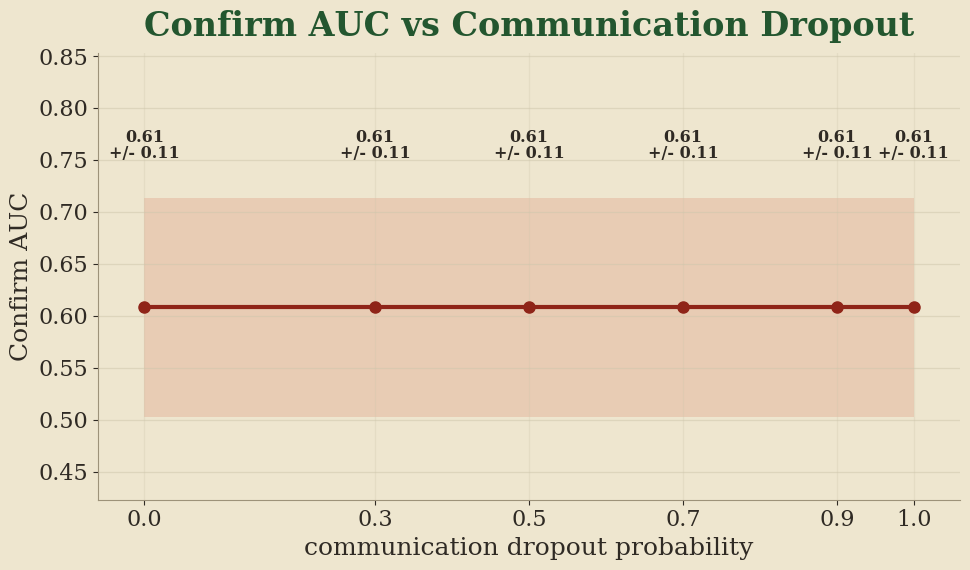

In [54]:
PAPER_BG = '#eee6cf'
GRID_COLOR = '#cfc7ad'
TEXT_GREEN = '#23562f'
TEXT_DARK = '#2f2a24'
CONFIRM_COLOR = '#8f2418'
SCOUT_COLOR = '#c94a27'
AUC_METRIC_SPECS = [
    ('confirm_auc', 'Confirm AUC', CONFIRM_COLOR, 's'),
    ('scout_auc', 'Scout AUC', SCOUT_COLOR, 'o'),
    ('confidence_auc', 'Confidence AUC', '#1f5a35', '^'),
    ('coverage_auc', 'Coverage AUC', '#5f812f', 'v'),
]


plot_df = metrics.copy()
if 'dropout_x' not in plot_df.columns:
    plot_df['dropout_x'] = plot_df.get('comms_dropout', float('nan'))
plot_df['dropout_x'] = pd.to_numeric(plot_df['dropout_x'], errors='coerce')
has_dropout_x = plot_df['dropout_x'].notna().all() and plot_df['dropout_x'].nunique() > 1

plt.rcParams.update({
    'figure.facecolor': PAPER_BG,
    'axes.facecolor': PAPER_BG,
    'axes.edgecolor': '#9d9279',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 24,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'text.color': TEXT_DARK,
    'axes.labelcolor': TEXT_DARK,
    'xtick.color': TEXT_DARK,
    'ytick.color': TEXT_DARK,
    'legend.frameon': True,
    'font.family': 'serif',
})


def _available_specs(specs, df):
    keep = []
    for prefix, label, color, marker in specs:
        col = f'{prefix}_mean'
        if col in df.columns and pd.to_numeric(df[col], errors='coerce').notna().any():
            keep.append((prefix, label, color, marker))
    return keep


def _add_bar_labels(ax, bars, std, *, offset_rank=0):
    for bar, err in zip(bars, std):
        height = bar.get_height()
        if not np.isfinite(height):
            continue
        err = 0.0 if not np.isfinite(err) else float(err)
        label_y = min(height + err + 0.028 + 0.028 * (offset_rank % 2), 1.20)
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            label_y,
            f'{height:.2f}\n+/- {err:.2f}',
            ha='center',
            va='bottom',
            fontsize=10.5,
            fontweight='bold',
            linespacing=0.9,
            color=TEXT_DARK,
        )


def _style_axis(ax):
    ax.grid(axis='y', color=GRID_COLOR, alpha=0.55, linewidth=0.9)
    ax.grid(axis='x', color=GRID_COLOR, alpha=0.30, linewidth=0.9)
    ax.spines['left'].set_color('#9d9279')
    ax.spines['bottom'].set_color('#9d9279')


def _plot_confirm_auc_curve(ax, df):
    df = df.sort_values('dropout_x')
    x = pd.to_numeric(df['dropout_x'], errors='coerce').to_numpy(dtype=float)
    mean = pd.to_numeric(df['confirm_auc_mean'], errors='coerce').to_numpy(dtype=float)
    std = pd.to_numeric(df['confirm_auc_std'], errors='coerce').to_numpy(dtype=float)
    valid = np.isfinite(x) & np.isfinite(mean)
    x = x[valid]
    mean = mean[valid]
    std = np.where(np.isfinite(std[valid]), std[valid], 0.0)
    if not len(x):
        ax.set_axis_off()
        ax.set_title('Confirm AUC vs Dropout not available', color=TEXT_GREEN, pad=12)
        return

    lower = np.clip(mean - std, 0.0, 1.0)
    upper = np.clip(mean + std, 0.0, 1.0)
    ax.fill_between(x, lower, upper, color=SCOUT_COLOR, alpha=0.16, linewidth=0)
    ax.plot(
        x,
        mean,
        color=CONFIRM_COLOR,
        marker='o',
        markersize=8,
        linewidth=3.0,
    )
    for xi, yi, err in zip(x, mean, std):
        ax.text(
            xi,
            min(yi + err + 0.035, 1.04),
            f'{yi:.2f}\n+/- {err:.2f}',
            ha='center',
            va='bottom',
            fontsize=11.5,
            fontweight='bold',
            linespacing=0.9,
            color=TEXT_DARK,
        )

    x_margin = max((float(np.nanmax(x)) - float(np.nanmin(x))) * 0.06, 0.01)
    y_min = max(float(np.nanmin(lower)) - 0.08, 0.0)
    y_max = min(max(float(np.nanmax(upper)) + 0.14, y_min + 0.2), 1.08)
    ax.set_xlim(float(np.nanmin(x)) - x_margin, float(np.nanmax(x)) + x_margin)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x)
    ax.set_title('Confirm AUC vs Communication Dropout', color=TEXT_GREEN, pad=12)
    ax.set_xlabel('communication dropout probability')
    ax.set_ylabel('Confirm AUC')
    _style_axis(ax)


def _plot_auc_group(ax, df, specs):
    specs = _available_specs(specs, df)
    if not specs:
        ax.set_axis_off()
        ax.set_title('Joint Diagnostic Time-Integrated Performance (AUC) not available', color=TEXT_GREEN, pad=12)
        return
    positions = np.arange(len(df))
    width = min(0.155, 0.68 / max(len(specs), 1))
    for offset, (prefix, label, color, _marker) in enumerate(specs):
        mean = pd.to_numeric(df[f'{prefix}_mean'], errors='coerce').to_numpy(dtype=float)
        std = pd.to_numeric(df[f'{prefix}_std'], errors='coerce').to_numpy(dtype=float)
        bar_x = positions + (offset - (len(specs) - 1) / 2) * width
        bars = ax.bar(
            bar_x,
            mean,
            width=width,
            yerr=std,
            capsize=3,
            color=color,
            alpha=0.98,
            label=label,
            edgecolor=PAPER_BG,
            linewidth=0.8,
            error_kw={'elinewidth': 1.0, 'alpha': 0.65, 'ecolor': TEXT_DARK},
        )
        _add_bar_labels(ax, bars, std, offset_rank=offset)
    labels = df['label'].str.replace(r' \| .*$', '', regex=True).tolist()
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=0, ha='center', fontweight='bold', fontsize=16)
    ax.set_title('Joint Diagnostic Time-Integrated Performance (AUC)', color=TEXT_GREEN, pad=12)
    ax.set_ylabel('Score')
    ax.set_ylim(0.0, 1.24)
    _style_axis(ax)
    legend = ax.legend(loc='lower right', title=None, fontsize=14)
    legend.get_frame().set_facecolor(PAPER_BG)
    legend.get_frame().set_edgecolor('#c8bea4')
    legend.get_frame().set_alpha(0.90)


if has_dropout_x:
    fig, ax = plt.subplots(figsize=(9.8, 5.8), facecolor=PAPER_BG)
    _plot_confirm_auc_curve(ax, plot_df)
else:
    plot_df = plot_df.reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(max(10, len(plot_df) * 1.4), 5.8), facecolor=PAPER_BG)
    _plot_auc_group(ax, plot_df, AUC_METRIC_SPECS)

fig.tight_layout()
plt.show()
